In [1]:
%load_ext autoreload
%autoreload 2

from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df, DMS_SHORTNAMES
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    # '250716-r1-explore-exploit-tension',
    '250812-r1-explore-exploit-tensionV2',
    []
)
mutant_df, round_metrics_df = convert_compaign_result_collection_to_df(results)
round_metrics_df['dms_shortname'] = round_metrics_df.dms_id.apply(lambda x: DMS_SHORTNAMES[x])
round_metrics_df['enrichment_1pct'] = round_metrics_df.held_out_batch_1pct / 0.01
round_metrics_df['enrichment_10pct'] = round_metrics_df.held_out_batch_10pct / 0.10

Loading results for DMSs: {'HSP82_YEAST_Flynn_2019', 'ANCSZ_Hobbs_2022', 'OXDA_RHOTO_Vanella_2023_activity', 'CBS_HUMAN_Sun_2020', 'BLAT_ECOLX_Firnberg_2014', 'HXK4_HUMAN_Gersing_2022_activity', 'SHOC2_HUMAN_Kwon_2022', 'PPM1D_HUMAN_Miller_2022', 'HEM3_HUMAN_Loggerenberg_2023'}


In [2]:
round_metrics_df.columns

Index(['dms_id', 'config_name', 'sim_num', 'variant_pool_size',
       'best_activity_this_round', 'best_percentile_this_round',
       'best_activity_so_far', 'normalized_best_activity_so_far',
       'best_percentile_so_far', 'cumulative_1pct_hits',
       'cumulative_10pct_hits', 'new_1pct_hits', 'new_10pct_hits',
       'has_found_top_1pct', 'round_num', 'model_spearman', 'misc',
       'held_out_activity_spearman', 'held_out_batch_1pct',
       'held_out_1pct_recall', 'held_out_1pct_recall_slate',
       'held_out_1pct_auc', 'held_out_batch_10pct', 'held_out_10pct_recall',
       'held_out_10pct_recall_slate', 'held_out_10pct_auc',
       'zero_shot_debug_info', 'few_shot_debug_info', 'dms_shortname',
       'enrichment_1pct', 'enrichment_10pct'],
      dtype='object')

/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_43530/2782986343.py:58: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'black'}` instead.

  sns.barplot(
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_43530/2782986343.py:58: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.barplot(
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_43530/2782986343.py:82: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'black'}` instead.

  sns.barplot(
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_43530/2782986343.py:82: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.barplot(
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_43530/2782986343.

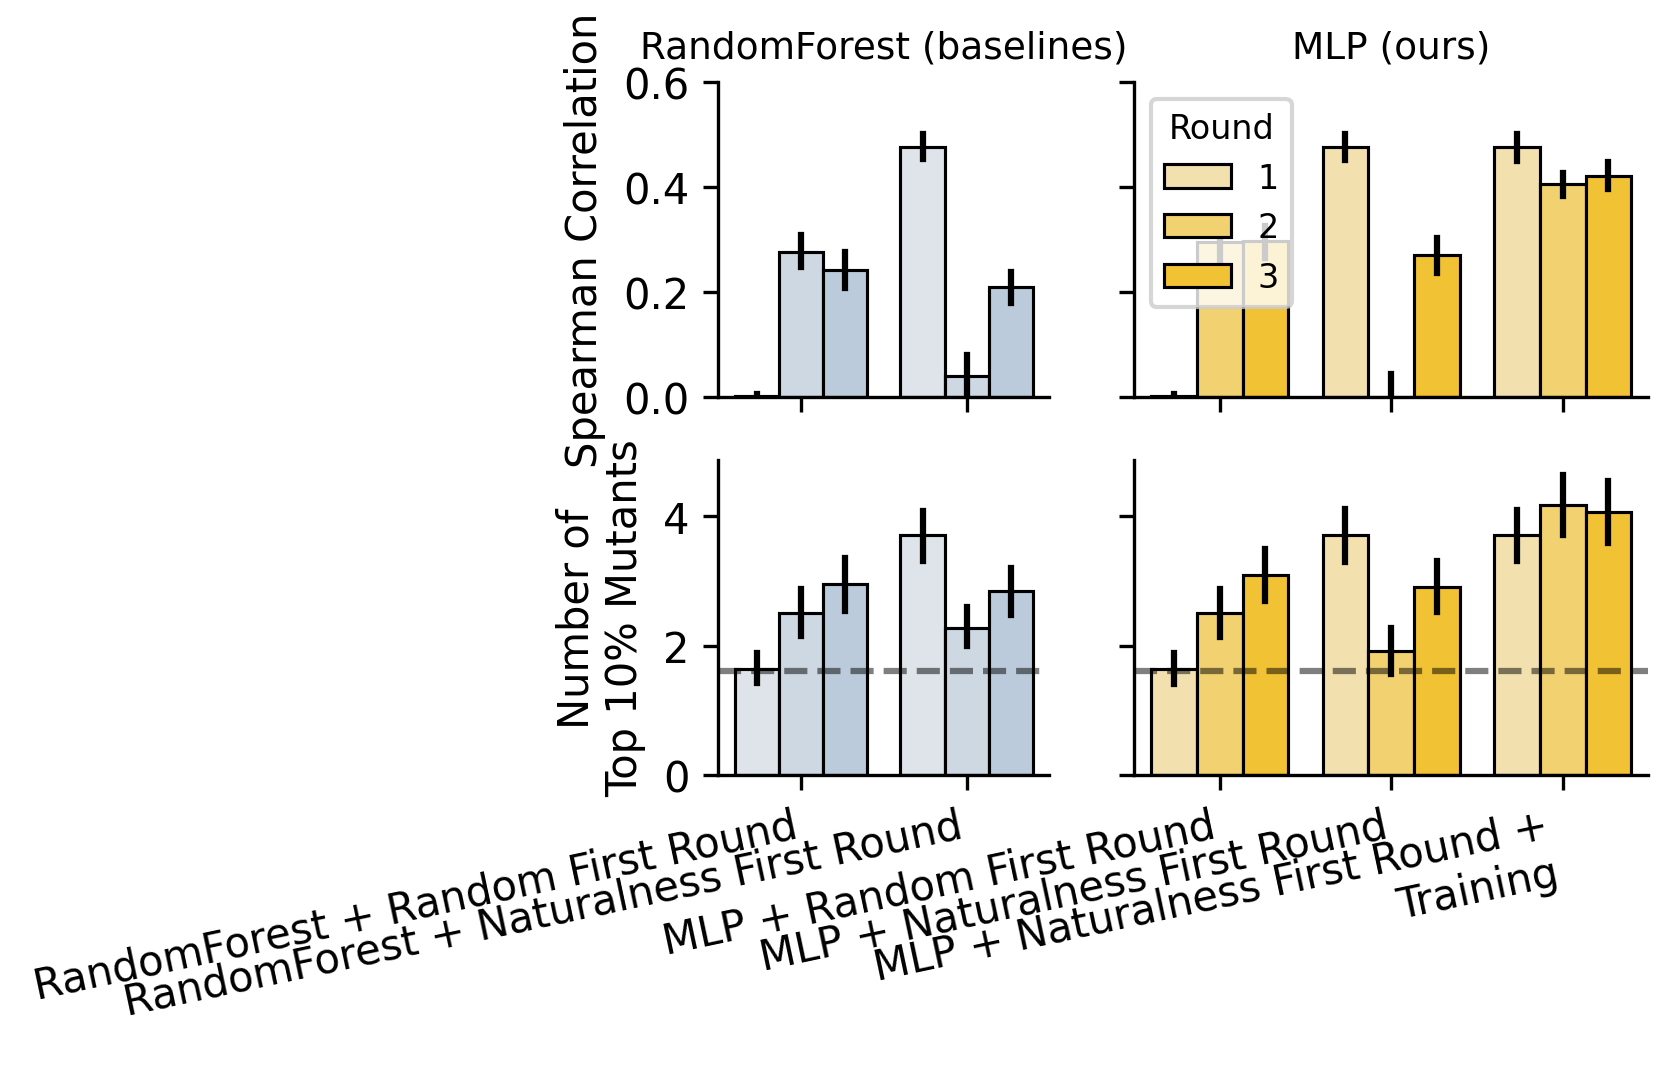

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

configs = [
    ('RandomForest-base', 'RandomForest + Random First Round'),
    ('RandomForest-naturalnessZeroShot', 'RandomForest + Naturalness First Round'),
    ('MLP-randomZeroShot', 'MLP + Random First Round'),
    ('MLP-naturalnessZeroShot', 'MLP + Naturalness First Round'),
    ('MLP-naturalnessZeroShot-natTraining', 'MLP + Naturalness First Round +\nTraining'),
    # ('MLP-naturalnessZeroShot-natTraining-5epochs', 'MLP + Naturalness First Round +\nTraining 5epoch'),
    # ('MLP-randomZeroShot-natTraining', 'Random First Round +\nTraining'),
]
metrics = [
    ("held_out_activity_spearman", np.nan, "Spearman Correlation"),
    ("new_10pct_hits", 1.6, "Number of\nTop 10% Mutants")
]


rf_palette = sns.light_palette('#bbcbdc', n_colors=4)
rf_round_palette = {
    1: rf_palette[-3],
    2: rf_palette[-2],
    3: rf_palette[-1]
}

mlp_palette = sns.light_palette('#F1C233', n_colors=4)
mlp_round_palette = {
    1: mlp_palette[-3],
    2: mlp_palette[-2],
    3: mlp_palette[-1]
}

# Optional deeper accent if you need to highlight “+ Training” in callouts elsewhere
mlp_deep_accent = "#9D0208"

# --- Prepare data & labels ---
config_map = dict(configs)
plot_df = round_metrics_df.copy()
plot_df["config_name"] = plot_df["config_name"].apply(lambda x: config_map.get(x, x))
plot_df["Round"] = plot_df["round_num"]

# Column orders per family
rf_order  = [label for key, label in configs if key.startswith("RandomForest-")]
mlp_order = [label for key, label in configs if key.startswith("MLP-")]

# --- Figure layout: 2 rows (metrics) × 2 cols (RF | MLP); scaled widths ---
fig, axs = plt.subplots(
    nrows=2, ncols=2, figsize=(4, 3), dpi=300,
    sharey="row", gridspec_kw={"width_ratios": [0.9, 1.4]}
)
hue_order = [1, 2, 3]  # rounds

for row, (metric, baseline, ylabel) in enumerate(metrics):
    # --- Left: RF ---
    axL = axs[row, 0]
    rf_data = plot_df[(plot_df.round_num <= 3) & (plot_df["config_name"].isin(rf_order))]
    sns.barplot(
        ax=axL, data=rf_data, x="config_name", y=metric,
        hue="Round", hue_order=hue_order, order=rf_order,
        palette=rf_round_palette,
        saturation=1.0,
        edgecolor='black', linewidth=0.75, errcolor='black', errwidth=1.5
    )
    axL.axhline(baseline, color="black", linewidth=1.5, alpha=0.5, linestyle="--")
    axL.set_ylabel(ylabel if row == 0 else ylabel)  # keep both visible
    if row == 0:
        axL.set_title("RandomForest (baselines)", fontsize=9)
    axL.set_xlabel("")
    # top row: hide x tick labels to reduce clutter
    if row == 0:
        axL.set_xticklabels([])
    else:
        axL.set_xticklabels(axL.get_xticklabels(), rotation=12, ha="right")

    # Remove duplicate legends; keep only top-right later
    axL.legend_.remove()

    # --- Right: MLP ---
    axR = axs[row, 1]
    mlp_data = plot_df[(plot_df.round_num <= 3) & (plot_df["config_name"].isin(mlp_order))]
    sns.barplot(
        ax=axR, data=mlp_data, x="config_name", y=metric,
        hue="Round", hue_order=hue_order, order=mlp_order,
        palette=mlp_round_palette,
        saturation=1.0,
        edgecolor='black', linewidth=0.75, errcolor='black', errwidth=1.5
    )
    axR.axhline(baseline, color="black", linewidth=1.5, alpha=0.5, linestyle="--")
    if row == 0:
        axR.set_title("MLP (ours)", fontsize=9)
    axR.set_xlabel("")
    if row == 0:
        axR.set_xticklabels([])
    else:
        axR.set_xticklabels(axR.get_xticklabels(), rotation=12, ha="right")

    # Keep legend only on the top-right panel
    if row == 1:
        axR.legend_.remove()

# Put a single legend for Rounds on the top-right axis
handles, labels = axs[0, 1].get_legend_handles_labels()
axs[0, 1].legend(handles, labels, title="Round", fontsize=8, title_fontsize=8, loc="upper left")

# Optional: match your previous y-limits for the second row
# axs[1, 0].set_ylim(0.00, 3.3)
# axs[1, 1].set_ylim(0.00, 3.3)
axs[0, 0].set_ylim(0.00, 0.6)
axs[0, 1].set_ylim(0.00, 0.6)

sns.despine(fig)
fig.tight_layout()
fig.savefig('notebooks/jacob/paperplots/fig2_r1_tension.svg', bbox_inches='tight', transparent=True)

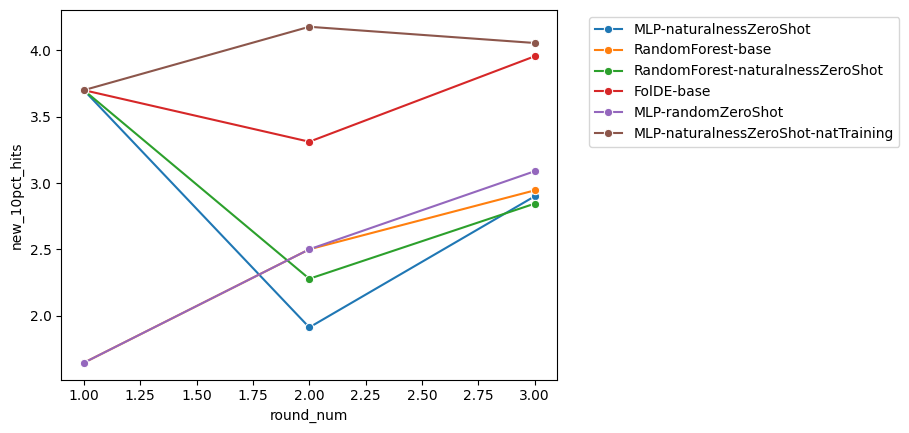

In [12]:
# Simplified version - top row only (Spearman Correlation)
REMOVE_ALL_TEXT = True

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(4, 1.5), dpi=300, gridspec_kw={"width_ratios": [0.9, 1.4]})

metric = "held_out_activity_spearman"
baseline = np.nan
ylabel = "Spearman Correlation"

# Left: RF
axL = axs[0]
rf_data = plot_df[(plot_df.round_num <= 3) & (plot_df["config_name"].isin(rf_order))]
sns.barplot(ax=axL, data=rf_data, x="config_name", y=metric, hue="Round", hue_order=[1, 2, 3], 
            order=rf_order, palette=rf_round_palette, saturation=1.0,
            edgecolor='black', linewidth=0.75, errcolor='black', errwidth=1.5)
axL.axhline(baseline, color="black", linewidth=1.5, alpha=0.5, linestyle="--")
axL.set_ylabel(ylabel)
axL.set_title("RandomForest (baselines)", fontsize=9)
axL.set_xlabel("")
axL.set_xticklabels(axL.get_xticklabels(), rotation=12, ha="right")
axL.legend_.remove()

# Right: MLP
axR = axs[1]
mlp_data = plot_df[(plot_df.round_num <= 3) & (plot_df["config_name"].isin(mlp_order))]
sns.barplot(ax=axR, data=mlp_data, x="config_name", y=metric, hue="Round", hue_order=[1, 2, 3],
            order=mlp_order, palette=mlp_round_palette, saturation=1.0,
            edgecolor='black', linewidth=0.75, errcolor='black', errwidth=1.5)
axR.axhline(baseline, color="black", linewidth=1.5, alpha=0.5, linestyle="--")
axR.set_title("MLP (ours)", fontsize=9)
axR.set_xlabel("")
axR.set_xticklabels(axR.get_xticklabels(), rotation=12, ha="right")
axR.set_ylim(0.00, 0.6)
axL.set_ylim(0.00, 0.6)

# Single legend on the right panel
handles, labels = axR.get_legend_handles_labels()
axR.legend(handles, labels, title="Round", fontsize=8, title_fontsize=8, loc="upper left")

if REMOVE_ALL_TEXT:
    # Remove all text elements for manual editing in Illustrator
    axL.set_ylabel("")
    axL.set_xlabel("")
    axL.set_title("")
    axL.set_xticklabels([])
    axL.set_yticklabels([])
    
    axR.set_ylabel("")
    axR.set_xlabel("")
    axR.set_title("")
    axR.set_xticklabels([])
    axR.set_yticklabels([])
    
    axR.legend_.remove()

sns.despine(fig)
fig.tight_layout()
fig.savefig('notebooks/jacob/paperplots/fig2_r1_tension_simplified.svg', bbox_inches='tight', transparent=True)